# End-to-End Usage Example (BERT-pivot)

This notebook demonstrates the full workflow for `intervene_enc` with the
bidirectional encoder + per-outcome (risk, time) task heads.

* **Phase 1** trains the embedder unchanged from the AR pipeline.
* **Phase 2** pre-trains the encoder with masked language modelling
  (atomic-interval mask + two time-aware auxiliaries).
* **Phase 3** attaches `TaskHeads` and fine-tunes for per-patient
  outcome risk + time-to-event regression.

Evaluation is a single forward pass: no autoregressive trajectory generation.


In [1]:
!nvidia-smi --query-gpu=name,memory.total,memory.free,compute_cap --format=csv,noheader


Tesla T4, 15360 MiB, 14913 MiB, 7.5


In [2]:
%pip install -e .


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: http://nexus.dgrs.idgmc.org.il/repository/pypi-proxy/simple/
Obtaining file:///workspace/notebooks/code/Predictions/INTERVenE-Enc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for intervene_enc (pyproject.toml) ... done
  Created wheel for intervene_enc: filename=intervene_enc-0.1-0.editable-py3-none-any.whl size=2803 sha256=53518bebbfa7046046447fff4c51672c4d08af3229f170c35452bbfb87eca8b8
  Stored in directory: /tmp/pip-ephem-wheel-cache-4jlsy5lw/wheels/26/9f/56/8078c894b287f760676739dbae1b3a45a3a0bd6ba450f3ca58
Successfully built intervene_enc
  Attempting uninstall: intervene_enc
    Found existing installation: intervene_enc 0.1
    Uninstalling intervene_enc-0.1:
      Successfully uninstalled intervene_enc

In [3]:
import importlib
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import intervene_enc.config.dataset_config as dataset_config
import intervene_enc.config.model_config as model_config
from intervene_enc import dataset, schedulers, utils, embedder, transformer, inference

# Preserve runtime keys (ctx_dim is set after we see the data; not in source).
_old_model_config = dict(getattr(model_config, "MODEL_CONFIG", {}))
_old_training_settings = dict(getattr(model_config, "TRAINING_SETTINGS", {}))

for module in (dataset_config, model_config, dataset, schedulers, utils,
               embedder, transformer, inference):
    importlib.reload(module)

for k, v in _old_model_config.items():
    model_config.MODEL_CONFIG.setdefault(k, v)
for k, v in _old_training_settings.items():
    model_config.TRAINING_SETTINGS.setdefault(k, v)

from intervene_enc.config.model_config import MODEL_CONFIG, TRAINING_SETTINGS

print(f"ctx_dim = {MODEL_CONFIG.get('ctx_dim')}  |  embed_dim = {MODEL_CONFIG.get('embed_dim')}")


ctx_dim = None  |  embed_dim = 128


In [4]:
# Optional cleanup controls for checkpoint artifacts.
CLEAN_SCALER = False
CLEAN_TOKENIZER = False
CLEAN_EMBEDDER = False
CLEAN_TRANSFORMER = False
CLEAN_ALL = True

clean_scaler      = CLEAN_SCALER or CLEAN_ALL
clean_tokenizer   = CLEAN_TOKENIZER or CLEAN_ALL
clean_embedder    = CLEAN_EMBEDDER or CLEAN_ALL
clean_transformer = CLEAN_TRANSFORMER or CLEAN_ALL

paths_to_delete = []
if clean_scaler:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "scaler.pkl")
if clean_tokenizer:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt")
if clean_embedder:
    p1 = Path(model_config.PHASE1_CHECKPOINT).resolve()
    paths_to_delete += [p1, p1.parent / "ckpt_last.pt"]
if clean_transformer:
    for ph in (model_config.PHASE2_CHECKPOINT, model_config.PHASE3_CHECKPOINT):
        ck = Path(ph).resolve()
        paths_to_delete += [ck, ck.parent / "ckpt_last.pt"]

removed, missing = [], []
for path in dict.fromkeys(paths_to_delete):
    if path.exists():
        try:
            path.unlink()
            removed.append(path)
        except Exception as e:
            print(f"  skip {path}: {e}")
    else:
        missing.append(path)
print(f"Cleanup: removed {len(removed)}, missing {len(missing)}")


Cleanup: removed 8, missing 0


## 1) Data Load and Processing


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Load source CSVs, normalise IDs, filter to the approved admission window, and
# build PERSON-GROUPED train / val / test splits.
#
# ID semantics: the pipeline treats `PatientId` as ONE trajectory — DataProcessor
# truncates after the first terminal event per PatientId, and EMRDataset builds one
# sequence per PatientId. So the model's unit of analysis is the ADMISSION:
#   VisitId   -> PatientId  (the sequence identifier)
#   person_id -> grouping key for splitting only; dropped before it reaches the model.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split as _tts
import numpy as _np

# --- Column names as they appear in the VM CSVs ---
PERSON_COL = "person_id"
VISIT_COL  = "VisitId"

# Context columns excluded from the model's context vector. person_id is dropped
# separately (after the split — it is needed as the grouping key until then).
CTX_DROP_COLS = [
    "CCI_LIKE_CATEGORY",       # string bucketing ("3-4", "5+") of numeric CCI_LIKE_SCORE
    "GTT_MEASURE",
    "HEIGHT_MEASURE",
    "WEIGHT_MEASURE",
    "HEMOGLOBIN-A1C_MEASURE",
]

# What to do with string / categorical context columns that survive CTX_DROP_COLS.
# DataProcessor casts the whole context frame to float32, so they cannot pass through.
#   "onehot" — one-hot encode below CTX_ONEHOT_MAX_CARD levels, drop above (default)
#   "drop"   — drop them all
#   "raise"  — stop and make me decide
CTX_NON_NUMERIC     = "onehot"
CTX_ONEHOT_MAX_CARD = 12

# --- Approved admission window: 2022-07-01 .. 2025-12-31 (upper bound exclusive) ---
ADMISSION_MIN = pd.Timestamp("2022-07-01")
ADMISSION_MAX = pd.Timestamp("2026-01-01")

_TEST_SPLIT          = 0.15
_RANDOM_SEED         = 42
TRAIN_VAL_SIZE       = 0.2
TRAIN_VAL_SPLIT_SEED = 42

NUM_WORKERS = 4  # dataloader worker processes (0 on Windows/Jupyter)

_SRC_DIR = Path(model_config.PROJECT_ROOT) / "data" / "source"
print(f"Loading source CSVs from {_SRC_DIR} ...")
_src_temporal = pd.read_csv(_SRC_DIR / "temporal_data.csv", low_memory=False)
_src_ctx      = pd.read_csv(_SRC_DIR / "context_data.csv")
print(f"  temporal: {len(_src_temporal):,} rows  cols={list(_src_temporal.columns)}")
print(f"  context : {len(_src_ctx):,} rows  cols={list(_src_ctx.columns)}")

# ── 1. Normalise the temporal IDs ────────────────────────────────────────────
# The temporal table is already visit-level: its `PatientId` IS the visit id.
# Accept either naming so the cell survives an upstream export change.
if VISIT_COL in _src_temporal.columns:
    _src_temporal = _src_temporal.rename(columns={VISIT_COL: "PatientId"})
    print(f"  temporal: renamed {VISIT_COL} -> PatientId")
elif "PatientId" in _src_temporal.columns:
    print("  temporal: PatientId already present, treating it as the visit id")
else:
    raise KeyError(f"temporal data has neither '{VISIT_COL}' nor 'PatientId': "
                   f"{list(_src_temporal.columns)}")

# ── 2. Context: source the visit -> person map, then make it numeric-only ────
if PERSON_COL not in _src_ctx.columns:
    raise KeyError(f"context data has no '{PERSON_COL}' column, so the split cannot be "
                   f"person-grouped; got {list(_src_ctx.columns)}")

if VISIT_COL in _src_ctx.columns:
    # Visit-level context (one row per admission) — the map lives right here.
    _visit2person = (_src_ctx[[VISIT_COL, PERSON_COL]]
                     .drop_duplicates()
                     .set_index(VISIT_COL)[PERSON_COL])
    _src_ctx = _src_ctx.rename(columns={VISIT_COL: "PatientId"})
    print("  context is visit-level -> renamed VisitId to PatientId")
else:
    raise KeyError(f"context has '{PERSON_COL}' but no '{VISIT_COL}', so visits cannot be "
                   f"attributed to persons; got {list(_src_ctx.columns)}")

if _visit2person.index.has_duplicates:
    _bad = int(_visit2person.index.duplicated().sum())
    raise ValueError(f"{_bad} {VISIT_COL}s map to >1 {PERSON_COL}; cannot group-split safely")

# Reconcile the two tables on the visit key before anything else depends on it.
_tmp_visits = pd.Index(_src_temporal["PatientId"].unique())
_ctx_visits = _visit2person.index
_no_ctx  = _tmp_visits.difference(_ctx_visits)
_no_evts = _ctx_visits.difference(_tmp_visits)
print(f"  visit key: {len(_tmp_visits):,} in temporal, {len(_ctx_visits):,} in context "
      f"| temporal-only={len(_no_ctx):,} context-only={len(_no_evts):,}")
if len(_no_ctx):
    # DataProcessor would silently invent -1 placeholder context rows for these.
    # Drop them instead so no visit trains on a fabricated context vector.
    print(f"  [warn] dropping {len(_no_ctx):,} visits with no context row "
          f"(e.g. {list(_no_ctx[:3])})")
    _src_temporal = _src_temporal[~_src_temporal["PatientId"].isin(_no_ctx)].copy()
    _tmp_visits = pd.Index(_src_temporal["PatientId"].unique())
_visit2person = _visit2person[_visit2person.index.isin(_tmp_visits)]
print(f"  {_visit2person.size:,} visits across {_visit2person.nunique():,} persons "
      f"({_visit2person.size / max(1, _visit2person.nunique()):.2f} visits/person)")

# Drop the excluded feature columns. A misspelt name would silently do nothing,
# so report what actually matched. (person_id is dropped after the split.)
_missing_drops = [c for c in CTX_DROP_COLS if c not in _src_ctx.columns]
if _missing_drops:
    print(f"  [warn] CTX_DROP_COLS names not present in context: {_missing_drops}")
_src_ctx = _src_ctx.drop(columns=[c for c in CTX_DROP_COLS if c in _src_ctx.columns])
print(f"  ctx: dropped {len([c for c in CTX_DROP_COLS if c not in _missing_drops])} "
      f"excluded columns")

# DataProcessor does `.astype("float32")` on the whole context frame, so every
# column must be numeric by the time it gets there. Resolve that here, BEFORE the
# split, so train / val / test end up with identical columns in identical order
# (the scaler is fit on one and applied positionally to the others).
_non_numeric = [c for c in _src_ctx.columns
                if c not in ("PatientId", PERSON_COL)
                and not pd.api.types.is_numeric_dtype(_src_ctx[c])]

# First: columns that are numeric in content but object in dtype (blank strings,
# stray whitespace, thousands separators). Coerce only when nothing is lost.
for _c in list(_non_numeric):
    _cleaned = (_src_ctx[_c].astype("string").str.strip()
                            .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "NULL": pd.NA}))
    _coerced = pd.to_numeric(_cleaned, errors="coerce")
    if int(_coerced.isna().sum()) <= int(_cleaned.isna().sum()):
        _src_ctx[_c] = _coerced.astype("float32")
        _non_numeric.remove(_c)
        print(f"  ctx '{_c}': object -> numeric (lossless coercion)")

# Then: genuinely categorical columns.
if _non_numeric:
    if CTX_NON_NUMERIC == "raise":
        raise TypeError(f"non-numeric context columns: {_non_numeric}. Set "
                        f"CTX_NON_NUMERIC to 'onehot'/'drop', or list them in CTX_DROP_COLS.")
    if CTX_NON_NUMERIC == "drop":
        print(f"  ctx: dropping non-numeric {_non_numeric}")
        _src_ctx = _src_ctx.drop(columns=_non_numeric)
    elif CTX_NON_NUMERIC == "onehot":
        for _c in _non_numeric:
            _card = int(_src_ctx[_c].nunique(dropna=True))
            if _card > CTX_ONEHOT_MAX_CARD:
                print(f"  ctx: dropping '{_c}' — {_card} levels > CTX_ONEHOT_MAX_CARD")
                _src_ctx = _src_ctx.drop(columns=[_c])
                continue
            # Sorted, explicit levels so the encoding is stable across reruns.
            _levels = sorted(_src_ctx[_c].astype("string").fillna("__MISSING__").unique())
            _dummies = pd.get_dummies(
                pd.Categorical(_src_ctx[_c].astype("string").fillna("__MISSING__"),
                               categories=_levels),
                prefix=_c, dtype="float32")
            _src_ctx = pd.concat([_src_ctx.drop(columns=[_c]),
                                  _dummies.set_index(_src_ctx.index)], axis=1)
            print(f"  ctx: one-hot '{_c}' ({_card} levels) -> {list(_dummies.columns)}")
    else:
        raise ValueError(f"unknown CTX_NON_NUMERIC={CTX_NON_NUMERIC!r}")

_ctx_feats = [c for c in _src_ctx.columns if c not in ("PatientId", PERSON_COL)]
assert all(pd.api.types.is_numeric_dtype(_src_ctx[c]) for c in _ctx_feats), "non-numeric ctx survived"
print(f"  context features (-> ctx_dim): {len(_ctx_feats)}")

# ── 3. Filter to the approved admission window ───────────────────────────────
for _c in ("StartDateTime", "EndDateTime"):
    _src_temporal[_c] = pd.to_datetime(_src_temporal[_c], format="ISO8601",
                                       utc=True, errors="raise").dt.tz_convert(None)

# Admission time per visit: the explicit ADMISSION_EVENT row where present, else
# the visit's earliest event (which is what DataProcessor uses as VisitStart).
_first_time = _src_temporal.groupby("PatientId")["StartDateTime"].min()
_adm_time = (_src_temporal.loc[_src_temporal["ConceptName"] == dataset_config.ADMISSION_TOKEN]
                          .groupby("PatientId")["StartDateTime"].min())
_n_no_adm = int(len(_first_time) - _adm_time.index.isin(_first_time.index).sum())
if _n_no_adm:
    print(f"  [warn] {_n_no_adm:,} visits have no {dataset_config.ADMISSION_TOKEN} row "
          f"-> using earliest event as admission time")
_admission_time = _adm_time.reindex(_first_time.index).fillna(_first_time)

_in_window = _admission_time[(_admission_time >= ADMISSION_MIN) &
                             (_admission_time <  ADMISSION_MAX)].index
print(f"  admissions in [{ADMISSION_MIN.date()} .. 2025-12-31]: {len(_in_window):,}"
      f" / {len(_admission_time):,} visits"
      f" ({100 * len(_in_window) / max(1, len(_admission_time)):.1f}%)")

_src_temporal = _src_temporal[_src_temporal["PatientId"].isin(_in_window)].copy()
_src_ctx      = _src_ctx[_src_ctx["PatientId"].isin(_in_window)].copy()
_visit2person = _visit2person[_visit2person.index.isin(_in_window)]
print(f"  after filter: {len(_src_temporal):,} temporal rows, {_visit2person.nunique():,} persons")

# ── 4. Person-grouped 70/15/15 split (no person spans two splits) ────────────
_all_persons = _np.sort(_visit2person.unique())
_trainval_persons, _test_persons = _tts(_all_persons, test_size=_TEST_SPLIT,
                                        random_state=_RANDOM_SEED)
_train_persons, _val_persons = _tts(_trainval_persons, test_size=TRAIN_VAL_SIZE,
                                    random_state=TRAIN_VAL_SPLIT_SEED)

def _visits_of(persons):
    """Visit (PatientId) index for a set of person_ids."""
    return _visit2person.index[_visit2person.isin(set(persons))]

train_ids        = _visits_of(_train_persons)
val_ids          = _visits_of(_val_persons)
_test_visits     = _visits_of(_test_persons)
_trainval_visits = train_ids.union(val_ids)

assert not (set(_train_persons) & set(_val_persons)), "person leak: train/val"
assert not (set(_trainval_persons) & set(_test_persons)), "person leak: trainval/test"
print(f"  persons  train={len(_train_persons):,} val={len(_val_persons):,} test={len(_test_persons):,}")
print(f"  visits   train={len(train_ids):,} val={len(val_ids):,} test={len(_test_visits):,}")

# Raw frames (cell 12 references eval_*_raw, so keep these names).
train_temporal_raw = _src_temporal[_src_temporal["PatientId"].isin(_trainval_visits)].copy()
train_ctx_raw      = _src_ctx[_src_ctx["PatientId"].isin(_trainval_visits)].copy()
eval_temporal_raw  = _src_temporal[_src_temporal["PatientId"].isin(_test_visits)].copy()
eval_ctx_raw       = _src_ctx[_src_ctx["PatientId"].isin(_test_visits)].copy()
del _src_temporal, _src_ctx

# person_id has served its purpose (the grouping key) — drop it now, before the
# frames reach DataProcessor. It must NOT survive: the context frame is cast to
# float32 wholesale, so person_id would become a model feature and leak identity.
# `PatientId` stays: DataProcessor consumes it as the join key and turns it into
# the context index, so it is never a feature either.
train_ctx_raw = train_ctx_raw.drop(columns=[PERSON_COL], errors="ignore")
eval_ctx_raw  = eval_ctx_raw.drop(columns=[PERSON_COL], errors="ignore")
assert PERSON_COL not in train_ctx_raw.columns and PERSON_COL not in eval_ctx_raw.columns
assert list(train_ctx_raw.columns) == list(eval_ctx_raw.columns), "train/eval ctx columns differ"

# Fill missing context values before DataProcessor: StandardScaler preserves NaN,
# and one NaN in a context vector makes that patient's whole sequence NaN.
# Medians come from the train+val pool only — same fit scope as the scaler.
_feat = [c for c in train_ctx_raw.columns if c != "PatientId"]
_medians = train_ctx_raw[_feat].median()
print(f"  context NaN before fill: train={int(train_ctx_raw[_feat].isna().sum().sum()):,}"
      f"  eval={int(eval_ctx_raw[_feat].isna().sum().sum()):,}")
train_ctx_raw[_feat] = train_ctx_raw[_feat].fillna(_medians)
eval_ctx_raw[_feat]  = eval_ctx_raw[_feat].fillna(_medians)
assert not train_ctx_raw[_feat].isna().any().any(), "NaN survived the fill (all-NaN column?)"
assert not eval_ctx_raw[_feat].isna().any().any(),  "NaN survived the fill (all-NaN column?)"

# Raw val frames — cell 3e re-processes val with max_input_days for the T fit.
val_temporal_raw = train_temporal_raw[train_temporal_raw["PatientId"].isin(val_ids)].copy()
val_ctx_raw      = train_ctx_raw[train_ctx_raw["PatientId"].isin(val_ids)].copy()


# ── 5. Process the train+val pool once (fits + saves the scaler) ─────────────
print("Processing train+val pool (fits scaler)...")
train_pool_processor = dataset.DataProcessor(
    train_temporal_raw.copy(), train_ctx_raw.copy(),
    scaler=None,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
)
train_pool_df, train_pool_ctx_df = train_pool_processor.run()
scaler = joblib.load(Path(model_config.CHECKPOINT_PATH) / "scaler.pkl")

# Tokenizer.
TOKENIZER_PATH = Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt"
if TOKENIZER_PATH.exists():
    tokenizer = dataset.EMRTokenizer.load(TOKENIZER_PATH)
else:
    tokenizer = dataset.EMRTokenizer.from_processed_df(train_pool_df)
    tokenizer.save(TOKENIZER_PATH)

# Every DataProcessor step except the scaler fit is per-PatientId, so slicing the
# processed pool is equivalent to re-processing val from raw — and saves a full
# pass over ~85% of the table.
train_temporal_df = train_pool_df[train_pool_df["PatientId"].isin(train_ids)].copy()
train_ctx_df      = train_pool_ctx_df[train_pool_ctx_df.index.isin(train_ids)].copy()
val_temporal_df   = train_pool_df[train_pool_df["PatientId"].isin(val_ids)].copy()
val_ctx_df        = train_pool_ctx_df[train_pool_ctx_df.index.isin(val_ids)].copy()

# ── 6. Test split: processed from raw with the fitted scaler ─────────────────
eval_temporal_df, eval_ctx_df = dataset.DataProcessor(
    eval_temporal_raw.copy(), eval_ctx_raw.copy(),
    scaler=scaler, tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
).run()

train_ds = dataset.EMRDataset(train_temporal_df, train_ctx_df, tokenizer=tokenizer)
val_ds   = dataset.EMRDataset(val_temporal_df,   val_ctx_df,   tokenizer=tokenizer)
eval_ds  = dataset.EMRDataset(eval_temporal_df,  eval_ctx_df,  tokenizer=tokenizer)

model_config.MODEL_CONFIG["ctx_dim"] = int(train_ds.context_df.shape[1])
print(f"ctx_dim -> {model_config.MODEL_CONFIG['ctx_dim']}")
print(f"Train visits: {len(train_ids):,} | Val: {len(val_ids):,} | "
      f"Eval: {eval_temporal_df['PatientId'].nunique():,}")

Loading source CSVs from /workspace/notebooks/code/Predictions/INTERVenE-Enc/data/source ...
  temporal: 19,142,783 rows  cols=['PatientId', 'ConceptName', 'StartDateTime', 'EndDateTime', 'Value']
  context : 98,050 rows  cols=['person_id', 'VisitId', 'gender_code', 'age_years', 'past6m_visits', 'past6m_emerg', 'past6m_inpt', 'BMI_MEASURE', 'WEIGHT_MEASURE', 'HEIGHT_MEASURE', 'HEMOGLOBIN-A1C_MEASURE', 'GTT_MEASURE', 'RDW-CV_MEASURE', 'ALCOHOL_ABUSE', 'ANEMIA', 'CANCER_DIAGNOSIS', 'CHRONIC_KIDNEY_CONDITION', 'CHRONIC_LIVER_DISEASE', 'DIABETES_DIAGNOSIS', 'HEART_DISEASE', 'DEMENTIA', 'RESPIRATORY_DISEASE', 'NERVOUS_SYSTEM_DISORDER', 'BASAL_HOME_BITZUA', 'SGLT2_HOME_BITZUA', 'METFORMIN_HOME_BITZUA', 'ANTIDIABETIC_HIGH_HYPO_HOME_BITZUA', 'ASPIRIN_CONTEXT', 'BP_ACE_CONTEXT', 'BP_ARB_CONTEXT', 'BP_BETA-BLOCKERS_CONTEXT', 'BP_CCB_CONTEXT', 'BP_LOOPS_CONTEXT', 'BP_OTHER_CONTEXT', 'BP_THIAZIDES_CONTEXT', 'MH_ANTIDEPRESSANT_CONTEXT', 'MH_ATYPICAL_CONTEXT', 'MH_MOOD_STABLIZER_CONTEXT', 'MH_TYPICA

## 2) Training


In [6]:
# Phase control flags — flip to False to skip a phase and load its checkpoint instead.
RUN_PHASE1      = True
RUN_PHASE2      = True
RUN_PHASE3      = True
RESUME_TRAINING = False
print(f"RUN_PHASE1={RUN_PHASE1}  RUN_PHASE2={RUN_PHASE2}  RUN_PHASE3={RUN_PHASE3}  RESUME={RESUME_TRAINING}")


RUN_PHASE1=True  RUN_PHASE2=True  RUN_PHASE3=True  RESUME=False


In [7]:
# DataLoaders — all three phases use the natural distribution.
bs = model_config.TRAINING_SETTINGS["batch_size"]
train_dl = dataset.get_dataloader(train_ds, batch_size=bs, collate_fn=dataset.collate_emr,
                                  oversample=False, bucket_batching=True, num_workers=NUM_WORKERS)
val_dl   = dataset.get_dataloader(val_ds,   batch_size=bs, collate_fn=dataset.collate_emr,
                                  oversample=False, bucket_batching=True, num_workers=NUM_WORKERS)
print(f"DataLoaders: train={len(train_dl)} batches  val={len(val_dl)} batches  (bs={bs})")


DataLoaders: train=2141 batches  val=541 batches  (bs=16)


[Logger] Logging to: /tmp/training_1000.log

  train_embedder  |  2026-08-28 12:43:35
  model config      : {'time2vec_dim': 32, 'embed_dim': 128, 'n_head': 2, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 49}
  training settings : {'phase1_n_epochs': 100, 'phase2_n_epochs': 300, 'phase3_n_epochs': 100, 'sample': None, 'lr_warmup_epochs': 5, 'early-stop-patience': 10, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0003, 'phase3_learning_rate': 0.0001, 'phase3_backbone_lr_factor': 0.1, 'phase3_weight_decay': 0.001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_terminal_bce_window_hours': 168.0, 'phase1_scheduler': {'main_only_epochs': 3, 'aux_fraction_caps': {'dt': 0.4}, 'order': [['dt']], 'ramp_epochs': {'dt': 0}, 'max_lambda': {'dt': 400.0}}, 'phase2_scheduler': {'main_only_epochs': 4, 'aux_fraction_caps': {'t_pos': 0.4, 't_local': 0.15}, 'order': [['t_pos', 't_local

Training:   0%|          | 0/2141 [00:00<?, ?it/s]

Validation:   0%|          | 0/541 [00:00<?, ?it/s]

[Phase-1] Epoch 001
            --> Train=0.3076 (BCE=0.3076  Δt=0.0000)
            --> Val=0.1026 (BCE=0.1026  Δt=0.0000)
            --> RawTrain dt=1.4562013


Training:   0%|          | 0/2141 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/541 [00:00<?, ?it/s]

[Phase-1] Epoch 042
            --> Train=0.0764 (BCE=0.0631  Δt=0.0133)
            --> Val=0.0757 (BCE=0.0625  Δt=0.0132)
            --> RawTrain dt=0.6342237


Training:   0%|          | 0/2141 [00:00<?, ?it/s]

Validation:   0%|          | 0/541 [00:00<?, ?it/s]

[Phase-1] Epoch 043
            --> Train=0.0764 (BCE=0.0631  Δt=0.0133)
            --> Val=0.0757 (BCE=0.0624  Δt=0.0132)
            --> RawTrain dt=0.6342228
[Phase-1]: Early stopping triggered.


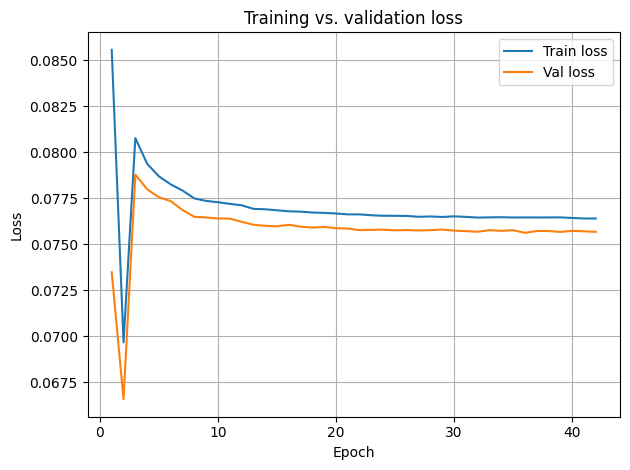

[InterveneEncoder]: Total params: 1.69 M

  pretrain_transformer  |  2026-08-28 13:35:47
  model config      : {'time2vec_dim': 32, 'embed_dim': 128, 'n_head': 2, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 49}
  training settings : {'phase1_n_epochs': 100, 'phase2_n_epochs': 300, 'phase3_n_epochs': 100, 'sample': None, 'lr_warmup_epochs': 5, 'early-stop-patience': 10, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0003, 'phase3_learning_rate': 0.0001, 'phase3_backbone_lr_factor': 0.1, 'phase3_weight_decay': 0.001, 'weight_decay': 0.001, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_terminal_bce_window_hours': 168.0, 'phase1_scheduler': {'main_only_epochs': 3, 'aux_fraction_caps': {'dt': 0.4}, 'order': [['dt']], 'ramp_epochs': {'dt': 0}, 'max_lambda': {'dt': 400.0}}, 'phase2_scheduler': {'main_only_epochs': 4, 'aux_fraction_caps': {'t_pos': 0.4, 't_local': 0.15}, 'order': [['t_pos', 't_lo

Training:   0%|          | 0/2141 [00:00<?, ?it/s]

Validation:   0%|          | 0/541 [00:00<?, ?it/s]

[Phase-2] Epoch 000  lr=3.259e-05
    --> Train=0.0000 (MLM=0.0000  tPos=0.0000  tLoc=0.0000)
    --> Val  =0.0000 (MLM=0.0000  tPos=0.0000  tLoc=0.0000)


Training:   0%|          | 0/2141 [00:00<?, ?it/s]

...

Training:   0%|          | 0/2141 [00:00<?, ?it/s]

Validation:   0%|          | 0/541 [00:00<?, ?it/s]

[Phase-2] Epoch 188  lr=2.846e-04
    --> Train=1.7783 (MLM=1.6449  tPos=0.0031  tLoc=0.1304)
    --> Val  =1.5564 (MLM=1.4414  tPos=0.0013  tLoc=0.1138)


Training:   0%|          | 0/2141 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [8]:
def _load_embedder_checkpoint(best_path, tokenizer):
    ckpt_best = Path(best_path).resolve()
    ckpt_last = ckpt_best.parent / "ckpt_last.pt"
    ckpt = ckpt_best if ckpt_best.exists() else ckpt_last
    if not ckpt.exists():
        raise FileNotFoundError("No Phase-1 checkpoint found. Set RUN_PHASE1=True first.")
    model, *_ = embedder.EMREmbedding.load(ckpt, tokenizer=tokenizer)
    return model


def _load_encoder_checkpoint(best_path, embedder_model, attach_task_heads=None):
    ckpt_best = Path(best_path).resolve()
    ckpt_last = ckpt_best.parent / "ckpt_last.pt"
    ckpt = ckpt_best if ckpt_best.exists() else ckpt_last
    if not ckpt.exists():
        raise FileNotFoundError(f"No checkpoint at {best_path}. Train the relevant phase first.")
    model, *_ = transformer.InterveneEncoder.load(ckpt, embedder=embedder_model,
                                            attach_task_heads=attach_task_heads)
    return model


# ----- Phase 1: embedder -----
if RUN_PHASE1:
    embedder_model = embedder.EMREmbedding(
        tokenizer=tokenizer,
        ctx_dim=model_config.MODEL_CONFIG["ctx_dim"],
        time2vec_dim=model_config.MODEL_CONFIG["time2vec_dim"],
        embed_dim=model_config.MODEL_CONFIG["embed_dim"],
    )
    embedder_model, _, _ = embedder.train_embedder(
        embedder=embedder_model,
        train_loader=train_dl, val_loader=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.PHASE1_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    embedder_model = _load_embedder_checkpoint(model_config.PHASE1_CHECKPOINT, tokenizer)

# ----- Phase 2: bidirectional MLM pre-training -----
if RUN_PHASE2:
    encoder = transformer.InterveneEncoder(cfg=model_config.MODEL_CONFIG, embedder=embedder_model)
    encoder, _, _ = transformer.pretrain_transformer(
        model=encoder, train_dl=train_dl, val_dl=val_dl,
        resume=RESUME_TRAINING, checkpoint_path=model_config.PHASE2_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    encoder = _load_encoder_checkpoint(model_config.PHASE2_CHECKPOINT, embedder_model,
                                       attach_task_heads=False)

# ----- Phase 3: outcome + time fine-tune -----
if RUN_PHASE3:
    if encoder.task_heads is None:
        encoder.attach_task_heads()
    encoder, _, _ = transformer.finetune_transformer(
        model=encoder, train_dl=train_dl, val_dl=val_dl,
        resume=RESUME_TRAINING, checkpoint_path=model_config.PHASE3_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    encoder = _load_encoder_checkpoint(model_config.PHASE3_CHECKPOINT, embedder_model,
                                       attach_task_heads=True)

encoder.eval()
print("Model ready for evaluation.")


## 3) Inference — single bidirectional pass

The encoder consumes the same `EMRDataset` as the AR pipeline but does **not**
generate a trajectory.  `inference.predict` returns a one-row-per-patient
dataframe with `P_<outcome>` (sigmoid of the risk-head logit) and
`T_<outcome>` (softplus of the time-head output, hours).


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Truncate test sequences to the same window the model is calibrated on.
EVAL_INPUT_DAYS = 2
print(f"Building truncated eval dataset ({EVAL_INPUT_DAYS}-day input window)...")
eval_input_processor = dataset.DataProcessor(
    eval_temporal_raw.copy(), eval_ctx_raw.copy(),
    scaler=scaler, tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
    max_input_days=EVAL_INPUT_DAYS,
)
eval_input_temporal_df, eval_input_ctx_df = eval_input_processor.run()
eval_ds_input = dataset.EMRDataset(eval_input_temporal_df, eval_input_ctx_df,
                                   tokenizer=tokenizer)

predictions = inference.predict(encoder, eval_ds_input,
                                batch_size=model_config.TRAINING_SETTINGS["batch_size"])
print(f"Predictions: {predictions.shape[0]} patients  cols={list(predictions.columns)[:6]} ...")
predictions.head()


### 3a) Ground-truth extraction


In [10]:
from intervene_enc.config.dataset_config import OUTCOME_RARE_THRESHOLD_PCT, RELEASE_TOKEN

EVAL_FULL_HORIZON_HOURS = 336.0
# Strict lower bound (hours) on positive-label events. Outcomes occurring inside
# [0, FORECAST_CUTOFF_HOURS] are observed in the model's input window and are
# not part of the forecasting task — including them as positives inflates AUPRC
# trivially. Matches evaluation.py and the STraTS / GRU-D preprocess convention.
FORECAST_CUTOFF_HOURS = float(EVAL_INPUT_DAYS) * 24.0
EVAL_PREVALENCE_THRESHOLD = OUTCOME_RARE_THRESHOLD_PCT / 100.0
AUC_EXCLUDE = (RELEASE_TOKEN,)  # P(release) is just 1 - P(death) here; report separately.

OUTCOME_NAMES = encoder.outcome_names


def extract_ground_truth(eval_ds, outcome_names,
                         min_event_time_hours=FORECAST_CUTOFF_HOURS):
    """Per-patient first-occurrence times from the un-truncated test sequences.
    Events at or before ``min_event_time_hours`` (the input seed window) are
    excluded so labels reflect forecasting, not detection of observed events."""
    outcome_set = set(outcome_names)
    gt = {}
    for pid in eval_ds.patient_ids:
        df = eval_ds.patient_groups[pid]
        patient_gt = {n: np.inf for n in outcome_names}
        for _, row in df.iterrows():
            tok = row["PositionToken"]
            if tok in outcome_set:
                t = row["TimePoint"]
                if t > min_event_time_hours and t < patient_gt[tok]:
                    patient_gt[tok] = t
        gt[pid] = patient_gt
    return gt


def extract_ground_truth_episodes(eval_ds, outcome_names,
                                  min_event_time_hours=FORECAST_CUTOFF_HOURS):
    """Per-patient all-occurrence times from the un-truncated test sequences.
    Events at or before ``min_event_time_hours`` (the input seed window) are
    excluded so per-outcome positives reflect the forecasting task."""
    outcome_set = set(outcome_names)
    gt = {}
    for pid in eval_ds.patient_ids:
        df = eval_ds.patient_groups[pid]
        patient_gt = {n: [] for n in outcome_names}
        for _, row in df.iterrows():
            tok = row["PositionToken"]
            if tok in outcome_set and row["TimePoint"] > min_event_time_hours:
                patient_gt[tok].append(row["TimePoint"])
        gt[pid] = patient_gt
    return gt


gt_first    = extract_ground_truth(eval_ds, OUTCOME_NAMES)
gt_episodes = extract_ground_truth_episodes(eval_ds, OUTCOME_NAMES)
print(f"GT extracted for {len(gt_first)} patients (positives gated to t > {FORECAST_CUTOFF_HOURS:.0f}h).")

summary = {n: sum(1 for p in gt_first if gt_first[p][n] < np.inf) for n in OUTCOME_NAMES}
pd.Series(summary, name="patients_with_complication").sort_values(ascending=False)

GT extracted for 7690 patients (positives gated to t > 48h).


RELEASE_EVENT                     7224
HYPERGLYCEMIA_EVENT               4311
SEVERE_HYPERGLYCEMIA_EVENT        3322
KIDNEY_COMPLICATION_EVENT          882
DEATH_EVENT                        466
HYPOGLYCEMIA_EVENT                 332
SEVERE_HYPOGLYCEMIA_EVENT          215
CARDIO-VASCULAR_DISORDER_EVENT     170
INFECTION_EVENT                    100
Name: patients_with_complication, dtype: int64

### 3b) Headline classification metrics


In [11]:
def _min_positives(n_patients, threshold=EVAL_PREVALENCE_THRESHOLD):
    return max(1, int(round(threshold * n_patients)))


def per_patient_auc(predictions, gt_episodes, outcome_names, min_positives=None):
    """
    Each patient contributes a single (risk_score, label) pair per outcome.
    risk_score = predictions.loc[pid, "P_<outcome>"]; label = 1 iff the outcome
    occurred strictly after the input observation window in the un-truncated GT
    trajectory (the filter is applied upstream when building ``gt_episodes``).
    """
    n_patients = predictions.shape[0]
    if min_positives is None:
        min_positives = _min_positives(n_patients)

    rows = []
    for name in outcome_names:
        pcol = f"P_{name}"
        if pcol not in predictions.columns:
            continue
        scores = predictions[pcol].to_numpy()
        labels = np.array([
            int(len(gt_episodes.get(pid, {}).get(name, [])) > 0)
            for pid in predictions.index
        ])
        n_pos = int(labels.sum()); n_neg = int(len(labels) - n_pos)
        prevalence = n_pos / max(1, n_pos + n_neg)
        if n_pos < min_positives or n_neg < min_positives:
            rows.append({"outcome": name, "auroc": np.nan, "auprc": np.nan,
                         "max_f1": np.nan, "f1_at_0_5": np.nan,
                         "n_pos": n_pos, "n_neg": n_neg, "prevalence": prevalence})
            continue
        precisions, recalls, thresholds = precision_recall_curve(labels, scores)
        f1s = np.where((precisions + recalls) > 0,
                       2 * precisions * recalls / np.maximum(precisions + recalls, 1e-12), 0.0)
        best_idx = int(np.argmax(f1s))
        max_f1 = float(f1s[best_idx])
        preds_05 = (scores >= 0.5).astype(int)
        tp = int(((preds_05 == 1) & (labels == 1)).sum())
        fp = int(((preds_05 == 1) & (labels == 0)).sum())
        fn = int(((preds_05 == 0) & (labels == 1)).sum())
        prec_05 = tp / max(tp + fp, 1); rec_05 = tp / max(tp + fn, 1)
        f1_at_0_5 = 2 * prec_05 * rec_05 / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0
        rows.append({
            "outcome": name,
            "auroc": float(roc_auc_score(labels, scores)),
            "auprc": float(average_precision_score(labels, scores)),
            "max_f1": max_f1, "f1_at_0_5": float(f1_at_0_5),
            "n_pos": n_pos, "n_neg": n_neg, "prevalence": prevalence,
        })
    return pd.DataFrame(rows).set_index("outcome").sort_values("auroc", ascending=False)


def weighted_mean_auc(auc_table, by="n_pos"):
    tbl = auc_table.dropna(subset=["auroc"])
    if len(tbl) == 0:
        nan = float("nan")
        return {"auroc_weighted": nan, "auprc_weighted": nan,
                "max_f1_weighted": nan, "f1_at_0_5_weighted": nan,
                "auroc_simple": nan, "auprc_simple": nan,
                "max_f1_simple": nan, "f1_at_0_5_simple": nan, "n_outcomes_used": 0}
    w = tbl[by].astype(float).values
    w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
    return {
        "auroc_weighted":     float((tbl["auroc"].values     * w).sum()),
        "auprc_weighted":     float((tbl["auprc"].values     * w).sum()),
        "max_f1_weighted":    float((tbl["max_f1"].values    * w).sum()),
        "f1_at_0_5_weighted": float((tbl["f1_at_0_5"].values * w).sum()),
        "auroc_simple":   float(tbl["auroc"].mean()),
        "auprc_simple":   float(tbl["auprc"].mean()),
        "max_f1_simple":  float(tbl["max_f1"].mean()),
        "f1_at_0_5_simple": float(tbl["f1_at_0_5"].mean()),
        "n_outcomes_used": int(len(tbl)),
    }


auc_outcome_names = [n for n in OUTCOME_NAMES if n not in AUC_EXCLUDE]
auc_table = per_patient_auc(predictions, gt_episodes, auc_outcome_names)
headline  = weighted_mean_auc(auc_table, by="n_pos")
print("\n[Patient AUC headline]")
for k in ("auroc_weighted", "auprc_weighted", "max_f1_weighted", "f1_at_0_5_weighted",
          "n_outcomes_used"):
    print(f"  {k:<22s} = {headline[k]:.4f}" if isinstance(headline[k], float) else
          f"  {k:<22s} = {headline[k]}")
auc_table.round(4)


[Patient AUC headline]
  auroc_weighted         = 0.7393
  auprc_weighted         = 0.6063
  max_f1_weighted        = 0.6103
  f1_at_0_5_weighted     = 0.0004
  n_outcomes_used        = 8


,auroc,auprc,max_f1,f1_at_0_5,n_pos,n_neg,prevalence
outcome,,,,,,,
CARDIO-VASCULAR_DISORDER_EVENT,0.7809,0.1893,0.2500,0.0000,170,7520,0.0221
HYPERGLYCEMIA_EVENT,0.7714,0.7829,0.7608,0.0009,4311,3379,0.5606
SEVERE_HYPERGLYCEMIA_EVENT,0.7328,0.6569,0.6577,0.0000,3322,4368,0.4320
KIDNEY_COMPLICATION_EVENT,0.7123,0.2857,0.3356,0.0000,882,6808,0.1147
SEVERE_HYPOGLYCEMIA_EVENT,0.6756,0.0737,0.1638,0.0000,215,7475,0.0280
HYPOGLYCEMIA_EVENT,0.6556,0.1004,0.1699,0.0000,332,7358,0.0432
DEATH_EVENT,0.6423,0.1008,0.1719,0.0000,466,7224,0.0606
INFECTION_EVENT,0.6122,0.0294,0.0433,0.0000,100,7590,0.0130


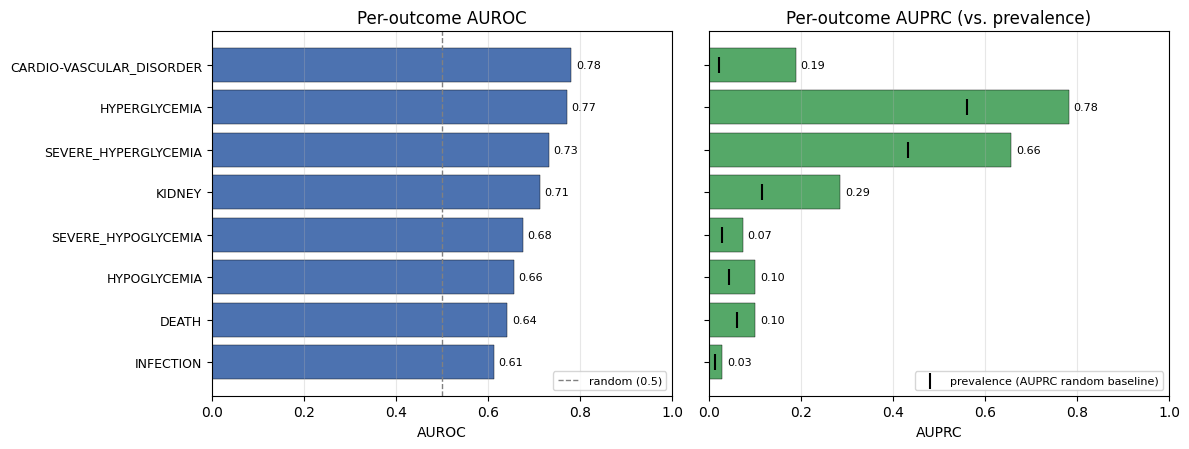

In [12]:
# Per-outcome AUROC / AUPRC barplot — quick visual of outcome ranking.
# AUPRC's random baseline is the per-outcome prevalence (n_pos / total), so
# we draw that as a small marker next to each bar: AUPRC clearly above its
# prevalence marker = real discrimination; close to it = base-rate inflation.
_plot_tbl = auc_table.dropna(subset=["auroc"]).copy()

if len(_plot_tbl) > 0:
    _plot_tbl = _plot_tbl.sort_values("auroc", ascending=True)
    _outcomes = [n.replace("_EVENT", "").replace("_COMPLICATION", "")
                 for n in _plot_tbl.index]
    _y = np.arange(len(_outcomes))

    fig, axes = plt.subplots(1, 2,
                             figsize=(12, max(3, 0.45 * len(_outcomes) + 1)),
                             sharey=True)

    # AUROC: 0.5 random baseline drawn as a vertical dashed line.
    axes[0].barh(_y, _plot_tbl["auroc"].values, color="#4C72B0",
                 edgecolor="black", linewidth=0.3)
    axes[0].axvline(0.5, color="gray", linestyle="--", lw=1, label="random (0.5)")
    axes[0].set_yticks(_y); axes[0].set_yticklabels(_outcomes, fontsize=9)
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel("AUROC")
    axes[0].set_title("Per-outcome AUROC")
    axes[0].legend(loc="lower right", fontsize=8)
    axes[0].grid(True, axis="x", alpha=0.3)
    for yi, v in zip(_y, _plot_tbl["auroc"].values):
        axes[0].text(min(v, 0.97) + 0.01, yi, f"{v:.2f}",
                     va="center", fontsize=8)

    # AUPRC: prevalence baseline drawn per outcome as a small grey marker.
    axes[1].barh(_y, _plot_tbl["auprc"].values, color="#55A868",
                 edgecolor="black", linewidth=0.3)
    axes[1].scatter(_plot_tbl["prevalence"].values, _y,
                    marker="|", s=120, color="black",
                    label="prevalence (AUPRC random baseline)")
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("AUPRC")
    axes[1].set_title("Per-outcome AUPRC (vs. prevalence)")
    axes[1].legend(loc="lower right", fontsize=8)
    axes[1].grid(True, axis="x", alpha=0.3)
    for yi, v in zip(_y, _plot_tbl["auprc"].values):
        axes[1].text(min(v, 0.97) + 0.01, yi, f"{v:.2f}",
                     va="center", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No outcomes met the min-positives threshold — nothing to plot.")


### 3c) Length-of-stay regression (RELEASE time head)


,MAE_hours,Median_hours,P90_hours,GT_mean_h,Pred_mean_h,n_patients
length_of_stay,65.09,43.01,162.13,129.89,67.92,7224


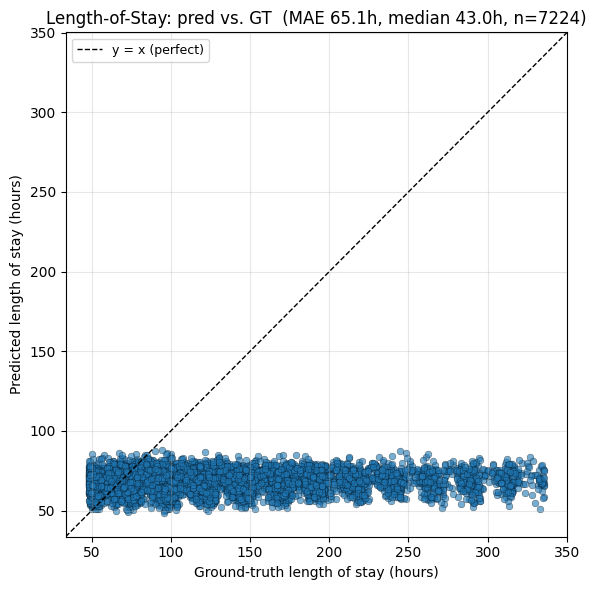

In [13]:
def length_of_stay_mae(predictions, gt_episodes, release_token=RELEASE_TOKEN):
    """
    LoS = predicted hours from sequence start to RELEASE — read from the
    time head's RELEASE slot.  GT LoS = first GT RELEASE_EVENT TimePoint.
    Returns the scalar summary plus the aligned (gt, pred) arrays so the
    caller can plot pred-vs-GT without re-walking the patient index.
    """
    tcol = f"T_{release_token}"
    if tcol not in predictions.columns:
        return {"mae_hours": float("nan"), "n_patients": 0,
                "gt_hours": np.array([]), "pred_hours": np.array([])}
    errs, gts, preds = [], [], []
    for pid in predictions.index:
        gt_releases = gt_episodes.get(pid, {}).get(release_token, [])
        if not gt_releases:
            continue
        gt_los   = float(min(gt_releases))
        pred_los = float(predictions.loc[pid, tcol])
        errs.append(abs(pred_los - gt_los))
        gts.append(gt_los); preds.append(pred_los)
    if not errs:
        return {"mae_hours": float("nan"), "n_patients": 0,
                "gt_hours": np.array([]), "pred_hours": np.array([])}
    arr   = np.asarray(errs)
    gts   = np.asarray(gts)
    preds = np.asarray(preds)
    return {
        "mae_hours":       float(arr.mean()),
        "median_hours":    float(np.median(arr)),
        "p90_hours":       float(np.percentile(arr, 90)),
        "n_patients":      int(len(arr)),
        "gt_mean_hours":   float(np.mean(gts)),
        "pred_mean_hours": float(np.mean(preds)),
        "gt_hours":        gts,
        "pred_hours":      preds,
    }


los = length_of_stay_mae(predictions, gt_episodes)

# Tabular summary — same metric panel rendered as a one-row DataFrame so it
# slots alongside the AUC / time-MAE tables above.
_los_summary = pd.DataFrame([{
    "MAE_hours":    los["mae_hours"],
    "Median_hours": los.get("median_hours", float("nan")),
    "P90_hours":    los.get("p90_hours",    float("nan")),
    "GT_mean_h":    los.get("gt_mean_hours",   float("nan")),
    "Pred_mean_h":  los.get("pred_mean_hours", float("nan")),
    "n_patients":   los["n_patients"],
}], index=["length_of_stay"]).round(2)
display(_los_summary)

# Pred-vs-GT scatter — diagonal is perfect prediction; under-the-diagonal
# means the model discharges patients too early, over-it means it overstays.
if los["n_patients"] >= 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(los["gt_hours"], los["pred_hours"], alpha=0.6, s=24,
               edgecolor="k", linewidth=0.3)
    _lo = float(min(los["gt_hours"].min(), los["pred_hours"].min()))
    _hi = float(max(los["gt_hours"].max(), los["pred_hours"].max()))
    _pad = 0.05 * (_hi - _lo + 1.0)
    _lo -= _pad; _hi += _pad
    ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=1, label="y = x (perfect)")
    ax.set_xlim(_lo, _hi); ax.set_ylim(_lo, _hi)
    ax.set_xlabel("Ground-truth length of stay (hours)")
    ax.set_ylabel("Predicted length of stay (hours)")
    ax.set_title(
        f"Length-of-Stay: pred vs. GT  "
        f"(MAE {los['mae_hours']:.1f}h, median {los['median_hours']:.1f}h, "
        f"n={los['n_patients']})"
    )
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough RELEASE_EVENT positives to draw a pred-vs-GT scatter.")


### 3d) Time-head MAE per outcome (positives only)


In [14]:
def time_head_mae(predictions, gt_episodes, outcome_names):
    """
    Mean absolute error between the time head's per-outcome prediction (hours
    from sequence start) and the *nearest* GT occurrence among patients where
    the outcome actually appears.
    """
    rows = []
    for name in outcome_names:
        tcol = f"T_{name}"
        if tcol not in predictions.columns:
            continue
        errs = []
        for pid in predictions.index:
            episodes = gt_episodes.get(pid, {}).get(name, [])
            if not episodes:
                continue
            pred_t = float(predictions.loc[pid, tcol])
            err = min(abs(pred_t - t_gt) for t_gt in episodes)
            errs.append(err)
        rows.append({"outcome": name,
                     "mae_hours": float(np.mean(errs)) if errs else float("nan"),
                     "n_patients": len(errs)})
    return pd.DataFrame(rows).set_index("outcome").sort_values("mae_hours")


time_mae_table = time_head_mae(predictions, gt_episodes, OUTCOME_NAMES)
time_mae_table.round(2)


,mae_hours,n_patients
outcome,,
HYPERGLYCEMIA_EVENT,13.43,4311
SEVERE_HYPERGLYCEMIA_EVENT,17.45,3322
CARDIO-VASCULAR_DISORDER_EVENT,23.30,170
KIDNEY_COMPLICATION_EVENT,36.04,882
HYPOGLYCEMIA_EVENT,43.60,332
SEVERE_HYPOGLYCEMIA_EVENT,44.25,215
INFECTION_EVENT,44.39,100
RELEASE_EVENT,65.09,7224
DEATH_EVENT,95.13,466


### 3e) Temperature calibration

Per-outcome temperature scaling on the risk-head logits.  Does not change rank
order; improves reliability of the reported probabilities.


In [15]:
import gc

@torch.no_grad()
def _collect_risk_logits(model, dataset_):
    """Run inference once and return raw risk logits aligned to outcome_names."""
    from torch.utils.data import DataLoader
    device = next(model.parameters()).device
    loader = DataLoader(dataset_, batch_size=model_config.TRAINING_SETTINGS["batch_size"],
                        shuffle=False, collate_fn=dataset.collate_emr, num_workers=0)
    chunks = []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        risk_logits, _, _, _ = model.predict(
            parent_raw_ids=batch["parent_raw_ids"],
            concept_ids=batch["concept_ids"],
            value_ids=batch["value_ids"],
            position_ids=batch["position_ids"],
            abs_ts=batch["abs_ts"],
            context_vec=batch["context_vec"],
        )
        chunks.append(risk_logits.cpu())
    return torch.cat(chunks, dim=0)


def _fit_T_per_outcome(logits, labels_dict, risk_names, n_iter=200, lr=0.05):
    """LBFGS fit of a per-outcome temperature on (logits, binary labels)."""
    temperatures = {}
    for j, name in enumerate(risk_names):
        labels = labels_dict[name]
        log_j = logits[:, j].float()
        if labels.sum() < 2:
            temperatures[name] = 1.0
            continue
        T = torch.nn.Parameter(torch.ones(1))
        opt = torch.optim.LBFGS([T], lr=lr, max_iter=n_iter)
        labels_t = torch.tensor(labels.astype(np.float32))
        def closure():
            opt.zero_grad()
            loss = torch.nn.functional.binary_cross_entropy_with_logits(log_j / T, labels_t)
            loss.backward()
            return loss
        opt.step(closure)
        temperatures[name] = float(T.item())
    return temperatures


def _ece(probs, labels, n_bins=15):
    """Expected Calibration Error: weighted |conf - acc| over n_bins equi-width bins."""
    probs = np.asarray(probs); labels = np.asarray(labels)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(probs)
    for k, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        upper = (probs <= hi) if k == n_bins - 1 else (probs < hi)
        mask = (probs >= lo) & upper
        if mask.sum() == 0:
            continue
        acc  = labels[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / N) * abs(conf - acc)
    return float(ece)


# --- 1) Build truncated VAL dataset (mirror cell 12) for T fit ---
print(f"Building truncated val dataset ({EVAL_INPUT_DAYS}-day input) for T fit ...")
val_input_processor = dataset.DataProcessor(
    val_temporal_raw.copy(), val_ctx_raw.copy(),
    scaler=scaler, tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
    max_input_days=EVAL_INPUT_DAYS,
)
val_input_temporal_df, val_input_ctx_df = val_input_processor.run()
val_ds_input = dataset.EMRDataset(val_input_temporal_df, val_input_ctx_df,
                                  tokenizer=tokenizer)

# --- 2) Extract val GT from un-truncated val_ds (built in cell 6) ---
val_gt_first = extract_ground_truth(val_ds, OUTCOME_NAMES)

# --- 3) Fit T per outcome on VAL ---
risk_idx   = encoder.task_heads.risk_idx.cpu().tolist()
risk_names = [encoder.outcome_names[i] for i in risk_idx]
val_logits = _collect_risk_logits(encoder, val_ds_input)
val_pids   = list(val_ds_input.patient_ids)
val_labels_dict = {n: np.array([int(val_gt_first.get(pid, {}).get(n, np.inf) < np.inf)
                                for pid in val_pids], dtype=np.float32)
                   for n in risk_names}
temperatures = _fit_T_per_outcome(val_logits, val_labels_dict, risk_names)
del val_input_processor, val_input_temporal_df, val_input_ctx_df, val_logits
gc.collect()

print("Per-outcome temperature T (fit on VAL; T>1 -> over-confident, T<1 -> under-confident):")
display(pd.Series(temperatures, name="temperature_T").sort_values().to_frame())

# --- 4) Collect TEST logits + labels for reliability + ECE ---
test_logits = _collect_risk_logits(encoder, eval_ds_input)
test_pids   = list(eval_ds_input.patient_ids)
cal_data = {}
for j, name in enumerate(risk_names):
    log_j = test_logits[:, j].float().numpy()
    lab_j = np.array([int(gt_first.get(pid, {}).get(name, np.inf) < np.inf)
                      for pid in test_pids], dtype=np.float32)
    cal_data[name] = (log_j, lab_j)

# --- 5) Apply T to TEST predictions; compute uncal/cal NLL/Brier/ECE on test ---
predictions_cal = predictions.copy()
for name, T in temperatures.items():
    pcol = f"P_{name}"
    if pcol not in predictions_cal.columns:
        continue
    p_uncal = predictions_cal[pcol].to_numpy().astype(np.float64)
    p_uncal = np.clip(p_uncal, 1e-7, 1 - 1e-7)
    logit  = np.log(p_uncal / (1.0 - p_uncal))
    predictions_cal[pcol] = 1.0 / (1.0 + np.exp(-logit / float(T)))
from intervene_enc.config.dataset_config import DEATH_TOKEN
if (f"P_{DEATH_TOKEN}" in predictions_cal.columns
        and f"P_{RELEASE_TOKEN}" in predictions_cal.columns):
    predictions_cal[f"P_{RELEASE_TOKEN}"] = 1.0 - predictions_cal[f"P_{DEATH_TOKEN}"]


def _per_outcome_calibration_metrics(predictions_df, gt_episodes, outcome_names):
    """Per-outcome AUROC / AUPRC / NLL / Brier / ECE on the test set."""
    rows = []
    for name in outcome_names:
        pcol = f"P_{name}"
        if pcol not in predictions_df.columns:
            continue
        scores = predictions_df[pcol].to_numpy().astype(np.float64)
        labels = np.array([int(len(gt_episodes.get(pid, {}).get(name, [])) > 0)
                           for pid in predictions_df.index], dtype=np.float64)
        n_pos = int(labels.sum()); n_neg = int(len(labels) - n_pos)
        if n_pos < 1 or n_neg < 1:
            rows.append({"outcome": name, "auroc": np.nan, "auprc": np.nan,
                         "nll": np.nan, "brier": np.nan, "ece": np.nan,
                         "n_pos": n_pos, "n_neg": n_neg})
            continue
        scores_c = np.clip(scores, 1e-7, 1 - 1e-7)
        nll = -float(np.mean(labels * np.log(scores_c) + (1 - labels) * np.log(1 - scores_c)))
        brier = float(np.mean((scores - labels) ** 2))
        rows.append({
            "outcome": name,
            "auroc": float(roc_auc_score(labels, scores)),
            "auprc": float(average_precision_score(labels, scores)),
            "nll":   nll,
            "brier": brier,
            "ece":   _ece(scores_c, labels, n_bins=15),
            "n_pos": n_pos, "n_neg": n_neg,
        })
    return pd.DataFrame(rows).set_index("outcome")


_uncal_metrics = _per_outcome_calibration_metrics(predictions,     gt_episodes, auc_outcome_names)
_cal_metrics   = _per_outcome_calibration_metrics(predictions_cal, gt_episodes, auc_outcome_names)

cal_compare = pd.DataFrame({
    "AUROC_uncal":  _uncal_metrics["auroc"],
    "AUROC_cal":    _cal_metrics["auroc"],
    "AUPRC_uncal":  _uncal_metrics["auprc"],
    "AUPRC_cal":    _cal_metrics["auprc"],
    "NLL_uncal":    _uncal_metrics["nll"],
    "NLL_cal":      _cal_metrics["nll"],
    "Brier_uncal":  _uncal_metrics["brier"],
    "Brier_cal":    _cal_metrics["brier"],
    "ECE_uncal":    _uncal_metrics["ece"],
    "ECE_cal":      _cal_metrics["ece"],
    "n_pos":        _uncal_metrics["n_pos"],
})
cal_compare["dNLL"]   = cal_compare["NLL_cal"]   - cal_compare["NLL_uncal"]
cal_compare["dBrier"] = cal_compare["Brier_cal"] - cal_compare["Brier_uncal"]
cal_compare["dECE"]   = cal_compare["ECE_cal"]   - cal_compare["ECE_uncal"]
print("\nBefore/after temperature scaling (T fit on val, evaluated on test) -- rank metrics unchanged; "
      "NLL/Brier/ECE should drop (negative delta).")
display(cal_compare.round(4))

_w = cal_compare["n_pos"].astype(float).values
_w = _w / _w.sum() if _w.sum() > 0 else np.ones_like(_w) / len(_w)
print(f"  weighted ECE_uncal = {(cal_compare['ECE_uncal'].values * _w).sum():.4f}")
print(f"  weighted ECE_cal   = {(cal_compare['ECE_cal'].values   * _w).sum():.4f}")
print(f"  weighted dNLL      = {(cal_compare['dNLL'].values      * _w).sum():+.4f}  (negative = better)")
print(f"  weighted dBrier    = {(cal_compare['dBrier'].values    * _w).sum():+.4f}  (negative = better)")
print(f"  weighted dECE      = {(cal_compare['dECE'].values      * _w).sum():+.4f}  (negative = better)")


Building truncated val dataset (2-day input) for T fit ...
[DataProcessor] Applied temporal filter: WHERE Value NOT LIKE '%Steady%' | rows 1773940 -> 1583834
[DataProcessor] QA features added: 13 columns, window=[0, 48.0h], 106559 qa rows in window.
Per-outcome temperature T (fit on VAL; T>1 -> over-confident, T<1 -> under-confident):


,temperature_T
INFECTION_EVENT,3.617371
CARDIO-VASCULAR_DISORDER_EVENT,3.962174
SEVERE_HYPOGLYCEMIA_EVENT,4.937341
HYPOGLYCEMIA_EVENT,5.266345
DEATH_EVENT,5.815175
KIDNEY_COMPLICATION_EVENT,7.397687
SEVERE_HYPERGLYCEMIA_EVENT,34.265308
HYPERGLYCEMIA_EVENT,54.575909



Before/after temperature scaling (T fit on val, evaluated on test) -- rank metrics unchanged; NLL/Brier/ECE should drop (negative delta).


,AUROC_uncal,AUROC_cal,AUPRC_uncal,AUPRC_cal,NLL_uncal,NLL_cal,Brier_uncal,Brier_cal,ECE_uncal,ECE_cal,n_pos,dNLL,dBrier,dECE
outcome,,,,,,,,,,,,,,
CARDIO-VASCULAR_DISORDER_EVENT,0.7809,0.7805,0.1893,0.1892,0.3286,0.1024,0.0221,0.0214,0.0221,0.0028,170,-0.2262,-0.0007,-0.0193
DEATH_EVENT,0.6423,0.6360,0.1008,0.0970,0.9455,0.2266,0.0606,0.0567,0.0606,0.0125,466,-0.7190,-0.0039,-0.0481
HYPERGLYCEMIA_EVENT,0.7714,0.7687,0.7829,0.7796,7.6533,0.7109,0.5600,0.2588,0.5602,0.1258,4311,-6.9424,-0.3012,-0.4344
HYPOGLYCEMIA_EVENT,0.6556,0.5925,0.1004,0.0822,0.6889,0.1770,0.0432,0.0412,0.0432,0.0022,332,-0.5119,-0.0019,-0.0409
INFECTION_EVENT,0.6122,0.6139,0.0294,0.0285,0.2054,0.0690,0.0130,0.0128,0.0130,0.0009,100,-0.1364,-0.0002,-0.0121
KIDNEY_COMPLICATION_EVENT,0.7123,0.7118,0.2857,0.2855,1.7144,0.3497,0.1146,0.1001,0.1147,0.0071,882,-1.3647,-0.0145,-0.1076
SEVERE_HYPERGLYCEMIA_EVENT,0.7328,0.7135,0.6569,0.6341,6.4282,0.6818,0.4317,0.2444,0.4319,0.0421,3322,-5.7463,-0.1874,-0.3897
SEVERE_HYPOGLYCEMIA_EVENT,0.6756,0.5358,0.0737,0.0382,0.4493,0.1286,0.0280,0.0272,0.0280,0.0090,215,-0.3207,-0.0007,-0.0190


  weighted ECE_uncal = 0.4087
  weighted ECE_cal   = 0.0712
  weighted dNLL      = -5.1896  (negative = better)
  weighted dBrier    = -0.1976  (negative = better)
  weighted dECE      = -0.3375  (negative = better)


### 3f) Reliability diagrams


Saved reliability figure to /workspace/notebooks/code/Predictions/INTERVenE-Enc/images/reliability.png


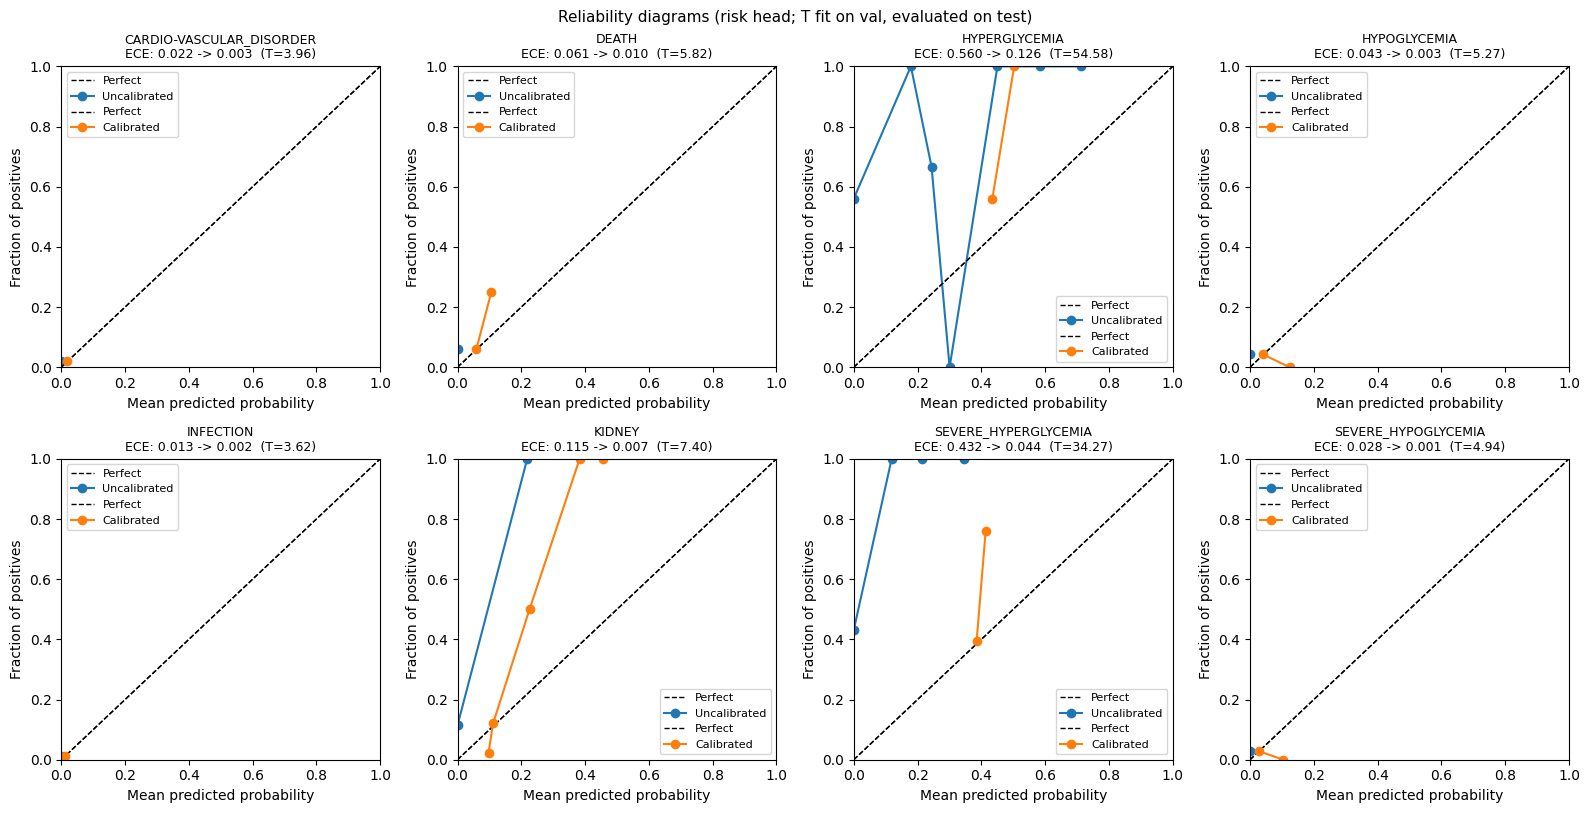

In [16]:
def reliability_diagram(ax, logits, labels, T=1.0, n_bins=10, label=""):
    probs = torch.sigmoid(torch.tensor(logits) / T).numpy()
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, mean_true = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            bin_centers.append(probs[mask].mean())
            mean_true.append(labels[mask].mean())
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
    ax.plot(bin_centers, mean_true, "o-", label=label)
    ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)


eligible = [n for n in cal_data if cal_data[n][1].sum() >= 5]
n_plots = min(len(eligible), 8)
if n_plots:
    fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(4 * ((n_plots + 1) // 2), 8))
    axes = np.atleast_1d(axes).flatten()
    for ax, name in zip(axes, eligible[:n_plots]):
        logits_np, labels_np = cal_data[name]
        probs_uncal = torch.sigmoid(torch.tensor(logits_np)).numpy()
        probs_cal   = torch.sigmoid(torch.tensor(logits_np) / temperatures[name]).numpy()
        ece_un = _ece(probs_uncal, labels_np, n_bins=15)
        ece_ca = _ece(probs_cal,   labels_np, n_bins=15)
        title = name.replace("_EVENT", "").replace("_COMPLICATION", "")
        ax.set_title(f"{title}\nECE: {ece_un:.3f} -> {ece_ca:.3f}  (T={temperatures[name]:.2f})", fontsize=9)
        reliability_diagram(ax, logits_np, labels_np, T=1.0,                    label="Uncalibrated")
        reliability_diagram(ax, logits_np, labels_np, T=temperatures[name],     label="Calibrated")
    for ax in axes[n_plots:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.suptitle("Reliability diagrams (risk head; T fit on val, evaluated on test)", y=1.01, fontsize=11)
    out_path = Path(PROJECT_ROOT) / "images" / "reliability.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved reliability figure to {out_path}")
    plt.show()
else:
    print("Not enough positives for reliability diagrams.")
